# Agent2: constant TOD and real TD data → maps

This notebook runs both examples and embeds their PNG outputs. It uses the
`QUBIC_JUN26` environment as installed. All outputs stay beside this notebook.
The reusable implementation and CLI are in `real_data_to_map.py`.

Unlike the FI simulation example, both examples here use the **248-detector TD
at 150 GHz**, with intensity-only maps at nside32.

In [1]:
from pathlib import Path
import sys, json
HERE = Path.cwd().resolve()
if not (HERE / 'experiments.py').exists():
    HERE = HERE / 'Agent2 Version'
if not (HERE / 'experiments.py').exists():
    raise RuntimeError('Open this notebook from End22End or Agent2 Version')
sys.path.insert(0, str(HERE))
import real_data_to_map as rdm
assert Path(rdm.__file__).resolve().parent == HERE, 'Wrong version imported; restart kernel'
from experiments import *
from IPython.display import display, Image
print('Python:', sys.executable)
print('Outputs:', HERE)


Python: /home/iqueirolo/anaconda3/envs/QUBIC_JUN26/bin/python
Outputs: /home/iqueirolo/Documentos/Doctorado/Codigos/AI_agents/End22End/Agent2 Version


## (a) Every TES = 1 for one hour

The native cadence is measured from the example dataset's ASIC PPS timestamps
(approximately 157 Hz), not taken from the simulation dictionary's 1-second
period. A broadcast array represents every native sample as exactly 1 W for
`0 <= t < 3600 s`. A compact NPZ stores its value, shape and cadence losslessly.

Consecutive groups of 40 samples are averaged before building the acquisition,
with a simple smooth horizontal scan evaluated at bin centers. This is an
explicit reduced-resolution pointing approximation; the final partial bin is
reported. It avoids a multi-gigabyte native pointing matrix. A constant detector
signal need not be a uniform optical sky, because detector gains and beams differ.
The 1 W input is intentionally unrealistic and is only a plumbing test.

Info rog: Allocating (3503992,9) elements = 240.60003662109375 MiB in FSRMatrix.__init__.


Info rog: Allocating (3503992,9) elements = 240.60003662109375 MiB in FSRMatrix.__init__.


{
  "native_rate_Hz": 156.99595747866448,
  "native_samples": 565186,
  "detectors": 248,
  "duration_seconds": 3600,
  "last_native_sample_seconds": 3599.9971532821655,
  "constant_value_W": 1.0,
  "native_TOD_representation": "broadcast 248 \u00d7 n array of exact ones",
  "native_TOD_all_ones": true,
  "map_samples": 14129,
  "map_sample_period_s": 0.25478363037109375,
  "note": "Native TOD is exact; averaged-pointing acquisition is a reduced-resolution approximation.",
  "solver": {
    "iterations": 265,
    "error": 9.672697250732079e-05,
    "recomputed_relative_residual": 9.672697247121065e-05,
    "converged": true,
    "message": "",
    "tolerance": 0.0001,
    "maxiter": 1000,
    "fit_detector_offsets": false,
    "solved_pixels": 546,
    "coverage_mask_fraction": 0.0,
    "relative_TOD_fit_residual": 0.33216523656715985
  },
  "time_bin": 40,
  "discarded_tail_samples": 26,
  "rejected_blocks": 0
}


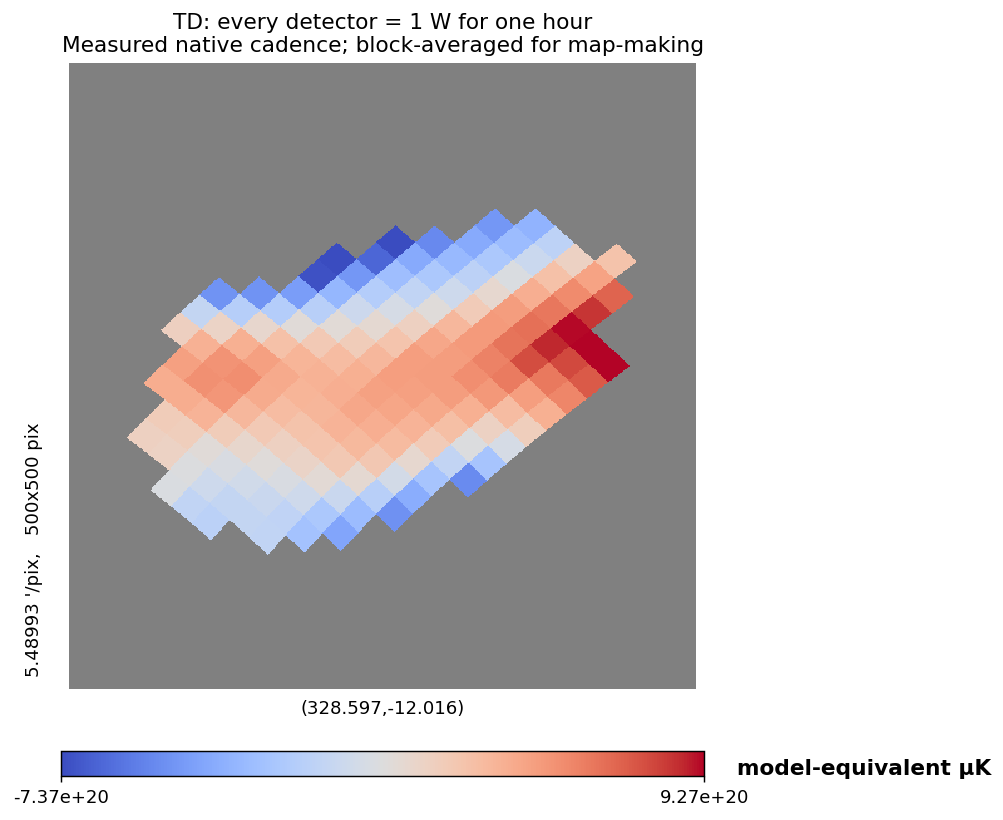

In [2]:
constant_info = constant_example()
assert constant_info['solver']['converged']
display(Image(filename=str(HERE/'figures/simple_constant_tod_map.png')))

## (b) Real galactic-plane dataset

We read actual TES and az/el timelines, verify all 248 QS detector indices,
clip to common telemetry support, unwrap azimuth, average 40-sample blocks and
fit one constant per detector simultaneously with the map. That fit projects
the same constant modes out of **both** TOD and the pointing operator; it assumes
white temporal noise. All covered pixels enter the solve; plots display coverage
above 15% of its peak.

**Units correction:** this installed qubicpack passes microamps to an amperes
formula when constructing its advertised Watt timelines. Our reader locally
recomputes electrical power using SI current. It changes only in-memory objects.
Electrical power is not calibrated optical sky power; current offsets, TES gain,
sign, optical responsivity, atmospheric signal and glitches remain unresolved.

HWP telemetry is missing. We therefore reconstruct only I under the assumption
Q=U=0 and pitch=0. These assumptions do not guarantee an unbiased intensity map.

Info rog: Allocating (2537288,9) elements = 174.22174072265625 MiB in FSRMatrix.__init__.


Info rog: Allocating (2537288,9) elements = 174.22174072265625 MiB in FSRMatrix.__init__.


{
  "dataset": "/home/iqueirolo/Documentos/Doctorado/Data/QUBIC/galactic_plane/2026-03-24/2026-03-24_07.25.31__galactic_plane_right_center_el50.0_52.0",
  "native_rates_Hz": [
    156.99595747866448,
    156.99595747866448
  ],
  "interpolated_rate_Hz": 157.15478286934692,
  "input_samples": 409600,
  "clipped_samples": 330,
  "hwp_available": false,
  "electrical_power_audit": [
    {
      "asic": 1,
      "bias_factor": 1.0,
      "original_power_percentiles": [
        -0.03698688919555973,
        -2.8317976387126956e-05,
        -4.437188144873762e-08
      ],
      "corrected_power_W_percentiles": [
        -5.806273238651496e-12,
        -3.618112855591448e-14,
        5.732310998844613e-12
      ]
    },
    {
      "asic": 2,
      "bias_factor": 1.0,
      "original_power_percentiles": [
        -0.03697535061132224,
        -3.5280736326619036e-05,
        -7.918415252851575e-09
      ],
      "corrected_power_W_percentiles": [
        -4.3107066389562487e-13,
        8.608

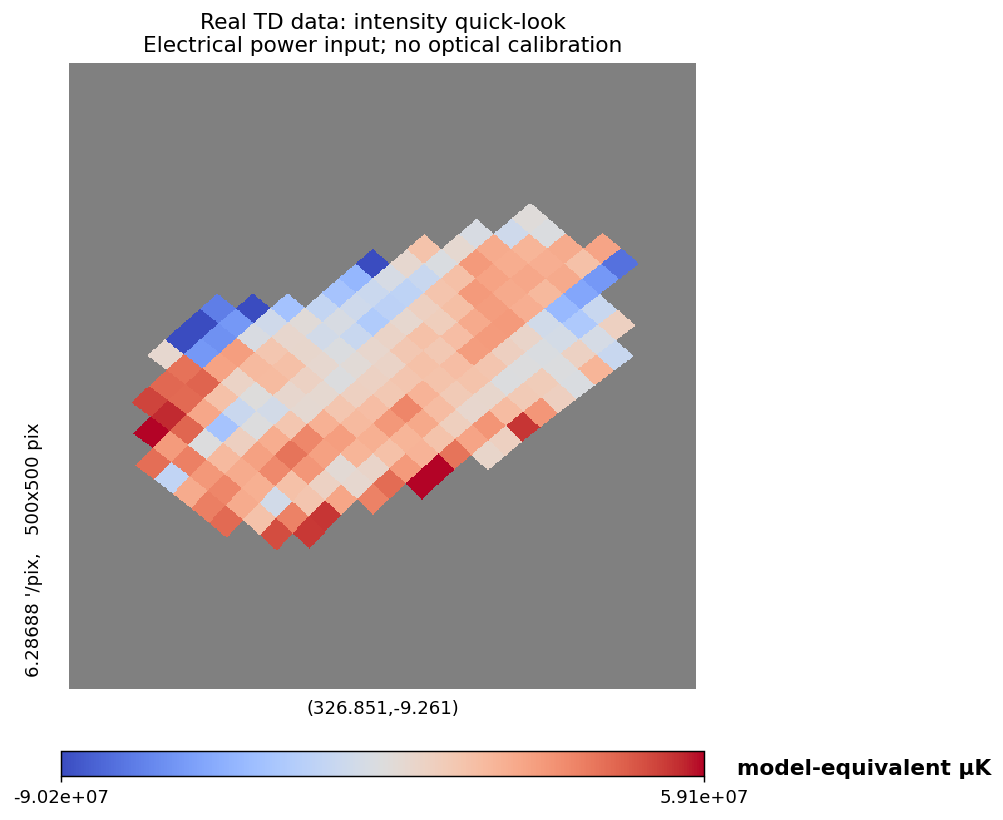

In [3]:
REAL_DATASET = DEFAULT_DATASET
real_map, real_cov, real_info = real_data_to_map(REAL_DATASET)
png = save_real_result(real_map,real_cov,real_info,HERE/'real_data_output')
print(json.dumps(real_info,indent=2))
assert real_info['solver']['converged']
display(Image(filename=str(png)))

## Read the real-data result cautiously

Numerical convergence of the normal equations and fidelity to measured TOD are
different checks. The metadata reports both. About 98% of the offset-projected
TOD norm remains in the fit residual for this example. Thus the image demonstrates
the pipeline and scan footprint; it does **not** establish a Galactic detection
or calibrated temperature map. The plotting values are model-equivalent µK,
because QubicScene's differential forward operator converts µK to watts.

## (c) Standalone CLI

```bash
conda activate QUBIC_JUN26
python "Agent2 Version/real_data_to_map.py" \
  2026-03-24_07.25.31__galactic_plane_right_center_el50.0_52.0
```

Use `--time-bin 40 --nside 32 --tol 1e-4 --maxiter 500` to specify defaults.
The CLI saves a one-dimensional I map, coverage, PNG and JSON metadata, and exits
with code 2 if PCG does not converge. Paths can also be supplied directly.
Default output location is anchored to the script, independent of your shell's
working directory. `--outdir` must remain inside Agent2 Version for this task.

In [4]:
import subprocess
help_result = subprocess.run([sys.executable,'-B',str(HERE/'real_data_to_map.py'),'--help'],capture_output=True,text=True,check=True)
print(help_result.stdout)

usage: real_data_to_map.py [-h] [--nside NSIDE] [--time-bin TIME_BIN]
                           [--tol TOL] [--maxiter MAXITER] [--keep-offsets]
                           [--outdir OUTDIR] [--verbose]
                           dataset

Agent2: QUBIC TD intensity quick-look using the QubicAcquisition + PCG solver.
The electrical-power input is not an optical-power calibration. Resulting
values are model-equivalent microkelvin, NOT calibrated sky temperature or
polarization.

positional arguments:
  dataset              Full dataset path or directory name in the default data
                       root

options:
  -h, --help           show this help message and exit
  --nside NSIDE
  --time-bin TIME_BIN  Average consecutive samples (default 40)
  --tol TOL
  --maxiter MAXITER
  --keep-offsets       Diagnostic: do not fit per-detector constants
  --outdir OUTDIR
  --verbose

